# Task 4: Loan Default Risk with Business Cost Optimization

**Objective:** Predict the likelihood of loan default and optimize the decision threshold with a business cost-benefit framework.

**Author:** Muneeb Ur Rehman | BS Information Technology, University of Sargodha  
**Dataset:** Home Credit Default Risk training data (`data/application_train.csv`: 307,511 records, 122 raw columns)  
**Target:** `TARGET` where `1` = default and `0` = repaid  
**Models:** Logistic Regression and CatBoost

---

## Problem Statement

Home credit companies face a critical challenge: lending to people without sufficient credit history. Two types of prediction errors carry very different financial consequences:

| Error Type | Scenario | Financial Impact |
|---|---|---|
| **False Negative** | Approve applicant who defaults | Loan loss |
| **False Positive** | Reject applicant who would have repaid | Lost interest revenue |

> A naive accuracy-maximizing model is not enough. We tune the **decision threshold** to minimize *total business cost*.


## 📦 1. Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix, roc_curve,
                              precision_recall_curve, average_precision_score)
from catboost import CatBoostClassifier

# ── Plot theme ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a', 'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444466',   'axes.labelcolor': '#e0e0ff',
    'xtick.color': '#aaaacc',      'ytick.color': '#aaaacc',
    'text.color': '#e0e0ff',       'grid.color': '#2a2a4a',
    'grid.alpha': 0.4,             'font.family': 'DejaVu Sans'
})
ACCENT  = '#7c6af7'; ACCENT2 = '#f7706a'; ACCENT3 = '#4fc3f7'
SUCCESS = '#66bb6a'; WARNING = '#ffa726'
print("✅ Libraries loaded")


✅ Libraries loaded


## 📂 2. Dataset Loading & Overview

**Source:** Home Credit Default Risk (Kaggle)  
The dataset captures applicant demographics, financials, and credit history.  
Target variable: `1` = loan defaulted, `0` = loan repaid.


## 2. Dataset Loading & Overview

**Source file:** `../data/application_train.csv`  
**Dataset:** Home Credit Default Risk training data from Kaggle.  
The dataset contains applicant demographics, financial variables, housing attributes, external credit scores, and document/request flags.

Target variable: `1` = loan defaulted, `0` = loan repaid.


In [6]:
df = pd.read_csv('../data/application_train.csv')
print(f"Shape     : {df.shape}")
print(f"Records   : {df.shape[0]:,}  |  Features: {df.shape[1]}")
print(f"Target Distribution:")
vc = df['TARGET'].value_counts().sort_index()
print(vc.to_string())
print(f"Default Rate: {df['TARGET'].mean()*100:.2f}%")
df.head()


Shape     : (307511, 122)
Records   : 307,511  |  Features: 122
Target Distribution:
TARGET
0    282686
1     24825
Default Rate: 8.07%


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
# 3.1 Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with Missing Values:")
print(pd.DataFrame({'Count': missing, 'Pct%': (missing/len(df)*100).round(2)}))


Columns with Missing Values:
                           Count   Pct%
COMMONAREA_MEDI           214865  69.87
COMMONAREA_MODE           214865  69.87
COMMONAREA_AVG            214865  69.87
NONLIVINGAPARTMENTS_MODE  213514  69.43
NONLIVINGAPARTMENTS_MEDI  213514  69.43
...                          ...    ...
EXT_SOURCE_2                 660   0.21
AMT_GOODS_PRICE              278   0.09
AMT_ANNUITY                   12   0.00
CNT_FAM_MEMBERS                2   0.00
DAYS_LAST_PHONE_CHANGE         1   0.00

[67 rows x 2 columns]


In [8]:
# 3.1 Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_table = pd.DataFrame({
    'Count': missing,
    'Pct%': (missing / len(df) * 100).round(2)
})
print(f"Columns with missing values: {len(missing_table)}")
print("Top 30 missing-value columns:")
print(missing_table.head(30).to_string())


Columns with missing values: 67
Top 30 missing-value columns:
                           Count   Pct%
COMMONAREA_MEDI           214865  69.87
COMMONAREA_MODE           214865  69.87
COMMONAREA_AVG            214865  69.87
NONLIVINGAPARTMENTS_MODE  213514  69.43
NONLIVINGAPARTMENTS_MEDI  213514  69.43
NONLIVINGAPARTMENTS_AVG   213514  69.43
FONDKAPREMONT_MODE        210295  68.39
LIVINGAPARTMENTS_AVG      210199  68.35
LIVINGAPARTMENTS_MEDI     210199  68.35
LIVINGAPARTMENTS_MODE     210199  68.35
FLOORSMIN_MEDI            208642  67.85
FLOORSMIN_MODE            208642  67.85
FLOORSMIN_AVG             208642  67.85
YEARS_BUILD_MODE          204488  66.50
YEARS_BUILD_MEDI          204488  66.50
YEARS_BUILD_AVG           204488  66.50
OWN_CAR_AGE               202929  65.99
LANDAREA_AVG              182590  59.38
LANDAREA_MEDI             182590  59.38
LANDAREA_MODE             182590  59.38
BASEMENTAREA_MODE         179943  58.52
BASEMENTAREA_MEDI         179943  58.52
BASEMENTAREA_AVG  

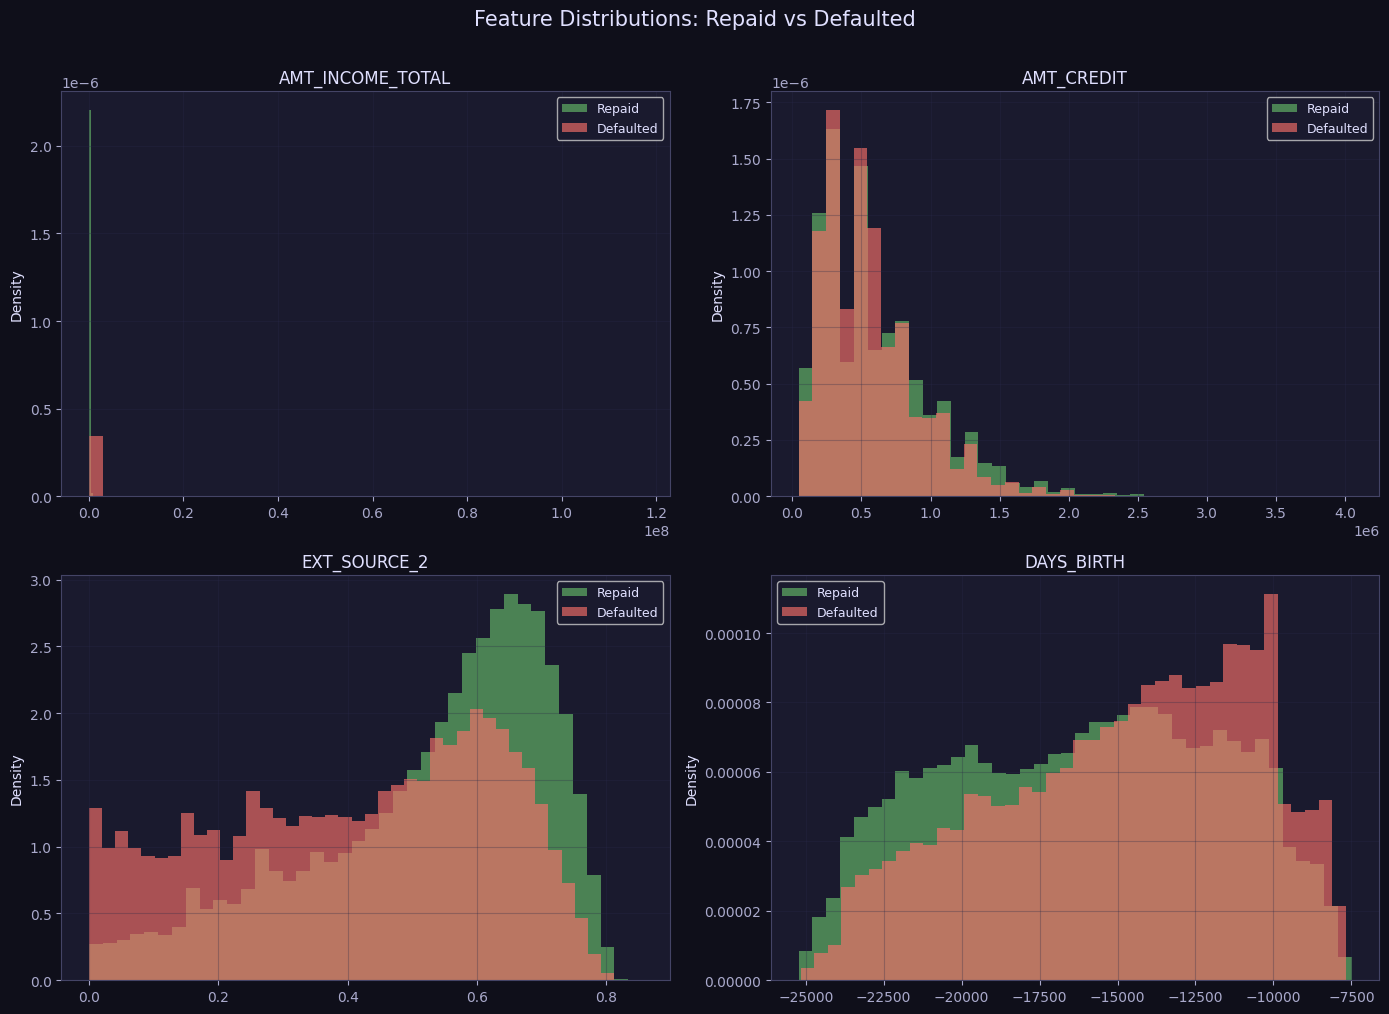

In [9]:
# 3.3 Feature distributions by target
num_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'EXT_SOURCE_2', 'DAYS_BIRTH']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#0f0f1a')
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    for tval, color, lbl in [(0, SUCCESS, 'Repaid'), (1, ACCENT2, 'Defaulted')]:
        ax.hist(df[df['TARGET']==tval][col].dropna(), bins=40,
                alpha=0.65, color=color, label=lbl, density=True, edgecolor='none')
    ax.set_title(col, fontsize=12); ax.set_ylabel('Density')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('Feature Distributions: Repaid vs Defaulted', fontsize=15, color='#e0e0ff', y=1.01)
plt.tight_layout()
plt.savefig('../images/feature_distributions.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


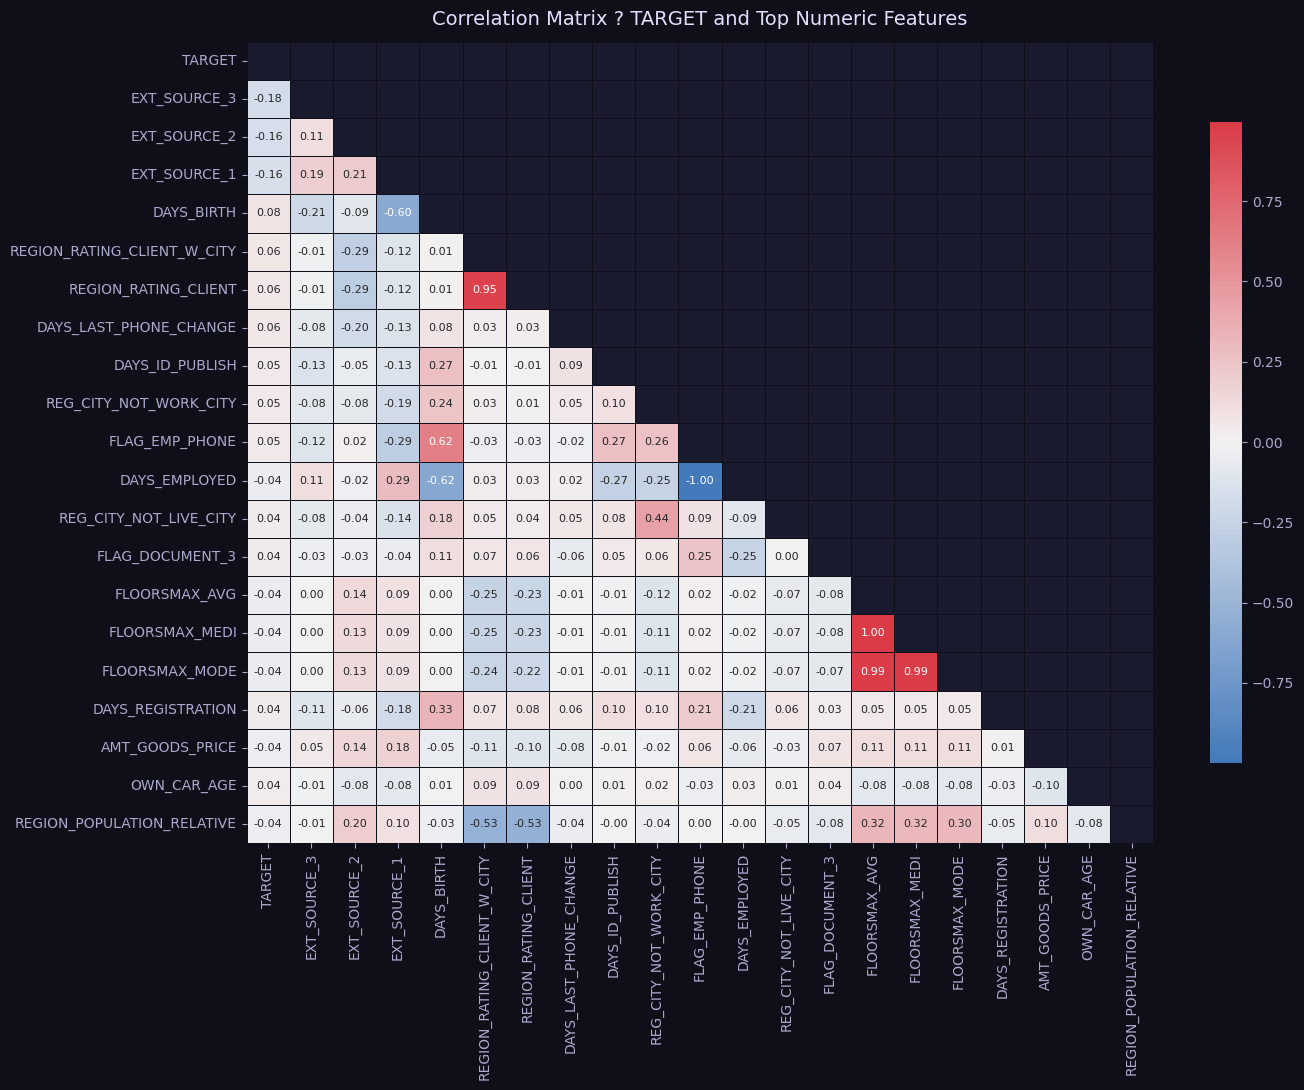

In [10]:
# 3.4 Correlation heatmap
# The full dataset has more than 100 numeric columns, so plotting every pair
# would be unreadable. Focus on TARGET and the 20 numeric features most
# correlated with it.
num_df = df.select_dtypes(include='number').drop(columns=['SK_ID_CURR'], errors='ignore')
target_corr = (
    num_df.corr(numeric_only=True)['TARGET']
    .drop('TARGET')
    .abs()
    .sort_values(ascending=False)
)
top_corr_cols = ['TARGET'] + target_corr.head(20).index.tolist()
corr = num_df[top_corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(14, 11))
fig.patch.set_facecolor('#0f0f1a')
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap=sns.diverging_palette(250,10,as_cmap=True),
            center=0, annot=True, fmt='.2f', annot_kws={'size': 8},
            linewidths=0.5, linecolor='#0f0f1a', ax=ax, cbar_kws={'shrink':0.8})
ax.set_title('Correlation Matrix ? TARGET and Top Numeric Features', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


## 4. Data Cleaning & Preprocessing

Steps performed:
- **Feature engineering:** Convert `DAYS_BIRTH` to `AGE_YEARS`, clean the Home Credit `DAYS_EMPLOYED=365243` sentinel before creating `EMPLOYMENT_YEARS`, and create credit/annuity-to-income ratios
- **Label-encode** categorical features for the baseline models
- **Stratified train/test split** (80/20) to preserve the default rate
- **Impute** missing values with medians learned from the training split


In [11]:
# 4.1 Feature engineering
df_clean = df.copy()

# Home Credit uses 365243 as a placeholder for unknown/not-applicable employment days.
df_clean['DAYS_EMPLOYED'] = df_clean['DAYS_EMPLOYED'].replace(365243, np.nan)

df_clean['AGE_YEARS']             = (-df_clean['DAYS_BIRTH']) / 365.25
df_clean['EMPLOYMENT_YEARS']      = (-df_clean['DAYS_EMPLOYED']) / 365.25
df_clean['CREDIT_INCOME_RATIO']   = df_clean['AMT_CREDIT'] / (df_clean['AMT_INCOME_TOTAL'] + 1)
df_clean['ANNUITY_INCOME_RATIO']  = df_clean['AMT_ANNUITY'] / (df_clean['AMT_INCOME_TOTAL'] + 1)

df_clean.drop(['SK_ID_CURR','DAYS_BIRTH','DAYS_EMPLOYED',
               'DAYS_REGISTRATION','DAYS_ID_PUBLISH'], axis=1, inplace=True, errors='ignore')
print(f"Shape after engineering: {df_clean.shape}")


Shape after engineering: (307511, 121)


In [12]:
# 4.2 Encode categoricals
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype('string').fillna('Missing'))

print(f"Categorical columns encoded: {len(cat_cols)}")
print(f"Shape after encoding      : {df_clean.shape}")


Categorical columns encoded: 16
Shape after encoding      : (307511, 121)


In [13]:
# 4.3 Train-test split and median imputation
X = df_clean.drop('TARGET', axis=1)
y = df_clean['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X.columns, index=X_test.index)

print(f"Train : {X_train.shape[0]:,} samples | Default rate: {y_train.mean()*100:.2f}%")
print(f"Test  : {X_test.shape[0]:,} samples | Default rate: {y_test.mean()*100:.2f}%")
print(f"Missing values remaining: {X_train.isnull().sum().sum() + X_test.isnull().sum().sum()}")


Train : 246,008 samples | Default rate: 8.07%
Test  : 61,503 samples | Default rate: 8.07%
Missing values remaining: 0


## 5. Model Building & Evaluation

Two models trained:
1. **Logistic Regression** - interpretable baseline with `class_weight='balanced'`
2. **CatBoost** - gradient boosting with `scale_pos_weight` to handle imbalance

Evaluation reports **ROC-AUC** and **average precision**. The final lending decision is selected by the business-cost threshold sweep, not by accuracy alone.


In [14]:
# 5.1 Logistic Regression with StandardScaler pipeline
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000,
                               random_state=42, C=0.5))
])
lr_pipe.fit(X_train, y_train)
lr_proba = lr_pipe.predict_proba(X_test)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_proba)
lr_ap    = average_precision_score(y_test, lr_proba)
print(f"Logistic Regression → AUC: {lr_auc:.4f}  |  Avg Precision: {lr_ap:.4f}")


Logistic Regression → AUC: 0.7462  |  Avg Precision: 0.2260


In [15]:
# 5.2 CatBoost with pos_weight for class imbalance
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Pos weight (neg/pos ratio): {pos_weight:.2f}")

cat_model = CatBoostClassifier(
    iterations=300, learning_rate=0.05, depth=5,
    scale_pos_weight=pos_weight, eval_metric='AUC',
    random_seed=42, verbose=0)
cat_model.fit(X_train, y_train, eval_set=(X_test, y_test))

cb_proba = cat_model.predict_proba(X_test)[:, 1]
cb_auc   = roc_auc_score(y_test, cb_proba)
cb_ap    = average_precision_score(y_test, cb_proba)
print(f"CatBoost            → AUC: {cb_auc:.4f}  |  Avg Precision: {cb_ap:.4f}")


Pos weight (neg/pos ratio): 11.39
CatBoost            → AUC: 0.7568  |  Avg Precision: 0.2457


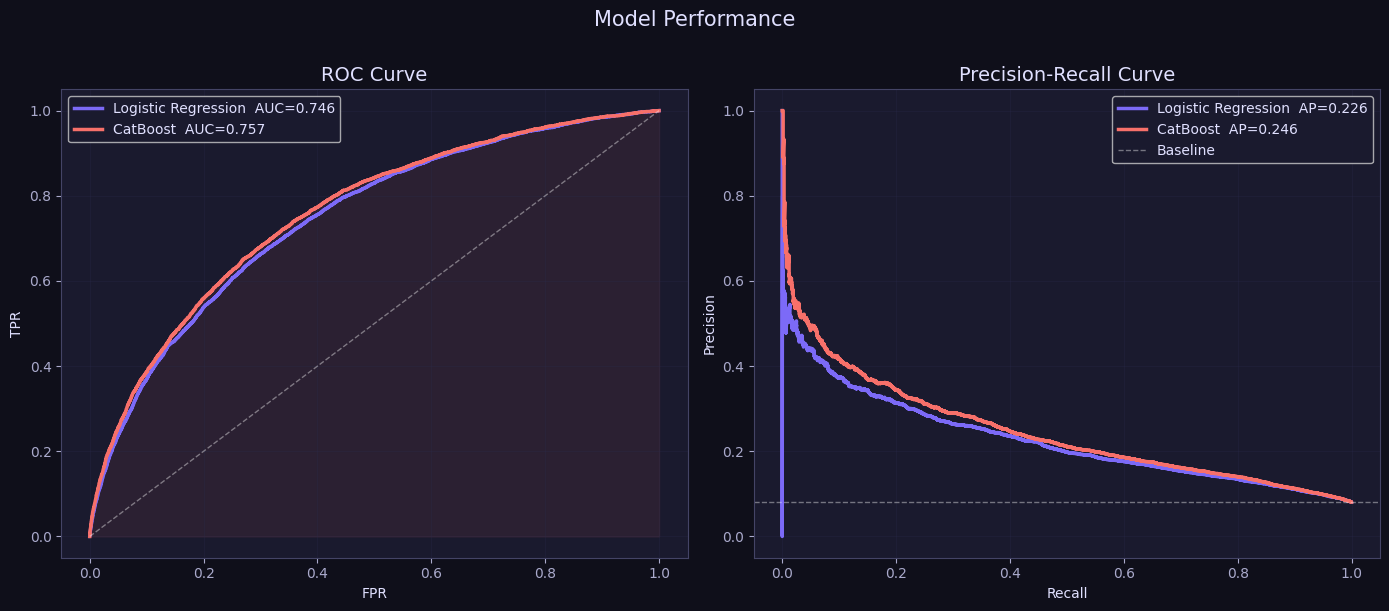

In [16]:
# 5.3 ROC and Precision-Recall curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0f0f1a')

for name, proba, color, auc, ap in [
    ('Logistic Regression', lr_proba, ACCENT,  lr_auc, lr_ap),
    ('CatBoost',            cb_proba, ACCENT2, cb_auc, cb_ap),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, lw=2.5, label=f'{name}  AUC={auc:.3f}')
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, color=color, lw=2.5, label=f'{name}  AP={ap:.3f}')

axes[0].plot([0,1],[0,1],'w--',lw=1,alpha=0.4)
axes[0].fill_between(*roc_curve(y_test,cb_proba)[:2], alpha=0.08, color=ACCENT2)
axes[0].set_title('ROC Curve',fontsize=14); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].legend(fontsize=10); axes[0].grid(alpha=0.3)

axes[1].axhline(y=y_test.mean(),color='w',lw=1,linestyle='--',alpha=0.4,label='Baseline')
axes[1].set_title('Precision-Recall Curve',fontsize=14); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=10); axes[1].grid(alpha=0.3)

plt.suptitle('Model Performance', fontsize=15, color='#e0e0ff', y=1.01)
plt.tight_layout()
plt.savefig('../images/roc_pr_curves.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


## 6. Business Cost Optimization

### Cost Matrix

| Scenario | Prediction | Reality | Cost Added |
|---|---|---|---:|
| Approve applicant who defaults | Repaid / negative | Default / positive | **$25,000** |
| Reject applicant who would repay | Default / positive | Repaid / negative | **$5,000** |
| Approve applicant who repays | Repaid / negative | Repaid / negative | $0 |
| Reject applicant who defaults | Default / positive | Default / positive | $0 |

We sweep thresholds 0.01 to 0.99 and find the point that **minimizes total cost**.


In [17]:
# 6.1 Cost parameters
COST_FN = 25000  # Approve → default (loan loss)
COST_FP = 5000   # Reject  → would-repay (lost revenue)
print(f"FN cost: ${COST_FN:,}  |  FP cost: ${COST_FP:,}  |  Ratio: {COST_FN/COST_FP:.0f}x")
print("→ Default is 5× more costly than rejecting a good customer → lean toward caution")


FN cost: $25,000  |  FP cost: $5,000  |  Ratio: 5x
→ Default is 5× more costly than rejecting a good customer → lean toward caution


In [18]:
# 6.2 Threshold sweep
thresholds = np.linspace(0.01, 0.99, 200)

def total_cost(y_true, proba, thresholds, cost_fn, cost_fp):
    costs = []
    for t in thresholds:
        y_pred = (proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
        costs.append(fn * cost_fn + fp * cost_fp)
    return np.array(costs)

lr_costs = total_cost(y_test, lr_proba, thresholds, COST_FN, COST_FP)
cb_costs = total_cost(y_test, cb_proba, thresholds, COST_FN, COST_FP)

lr_opt = thresholds[np.argmin(lr_costs)]
cb_opt = thresholds[np.argmin(cb_costs)]

print(f"LR  → Optimal threshold: {lr_opt:.3f} | Min cost: ${lr_costs.min():,.0f}")
print(f"CatBoost → Optimal threshold: {cb_opt:.3f} | Min cost: ${cb_costs.min():,.0f}")


LR  → Optimal threshold: 0.695 | Min cost: $106,320,000
CatBoost → Optimal threshold: 0.699 | Min cost: $103,760,000


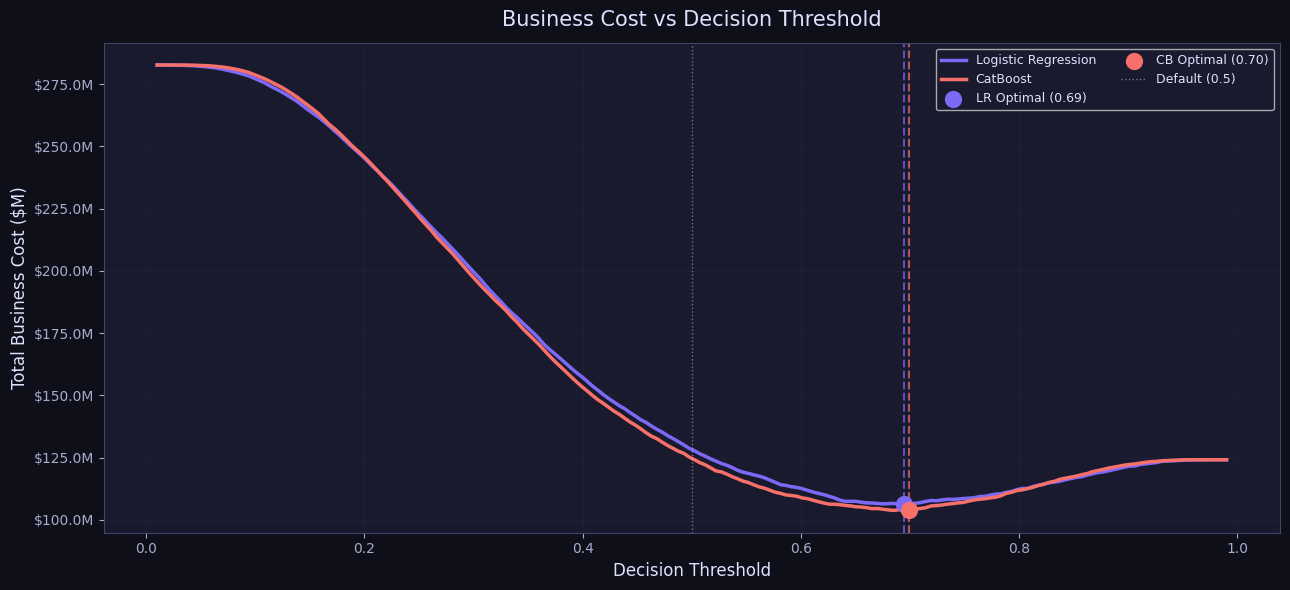

In [19]:
# 6.3 Cost vs threshold curve
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0f0f1a')

ax.plot(thresholds, lr_costs/1e6, color=ACCENT,  lw=2.5, label='Logistic Regression')
ax.plot(thresholds, cb_costs/1e6, color=ACCENT2, lw=2.5, label='CatBoost')
ax.axvline(lr_opt, color=ACCENT,  lw=1.5, linestyle='--', alpha=0.7)
ax.axvline(cb_opt, color=ACCENT2, lw=1.5, linestyle='--', alpha=0.7)
ax.scatter([lr_opt],[lr_costs.min()/1e6], color=ACCENT,  s=130, zorder=5, label=f'LR Optimal ({lr_opt:.2f})')
ax.scatter([cb_opt],[cb_costs.min()/1e6], color=ACCENT2, s=130, zorder=5, label=f'CB Optimal ({cb_opt:.2f})')
ax.axvline(0.5, color='white', lw=1, linestyle=':', alpha=0.4, label='Default (0.5)')
ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('Total Business Cost ($M)', fontsize=12)
ax.set_title('Business Cost vs Decision Threshold', fontsize=15, pad=12)
ax.legend(fontsize=9, ncol=2); ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('$%.1fM'))
plt.tight_layout()
plt.savefig('../images/cost_optimization.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


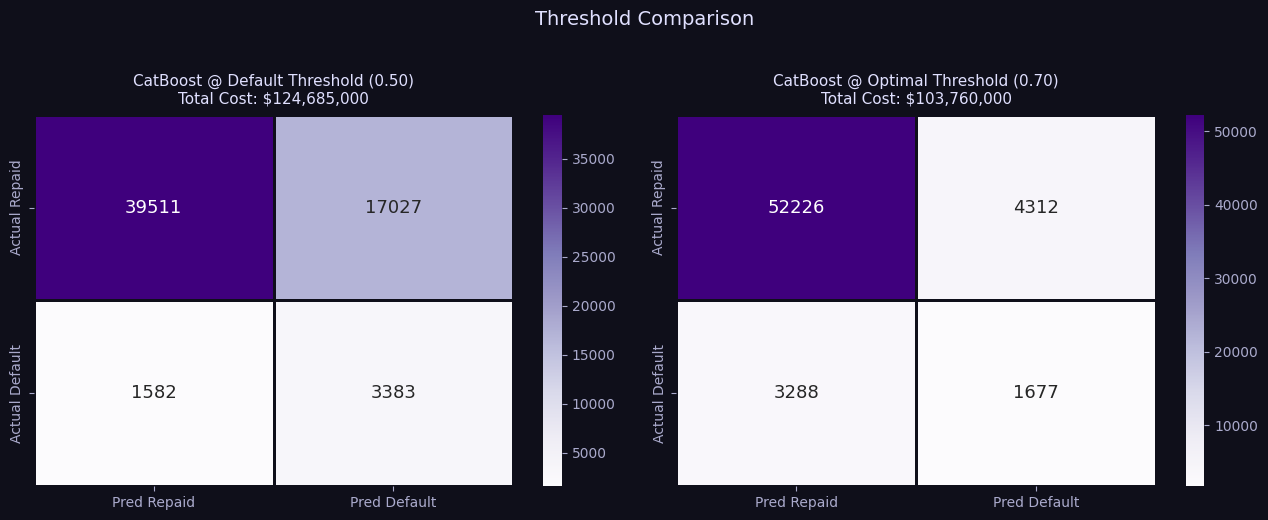

Default threshold cost : $124,685,000
Optimal threshold cost : $103,760,000
Cost savings           : $20,925,000  (16.8% reduction)


In [20]:
# 6.4 Confusion matrices: default vs optimal threshold
y_default = (cb_proba >= 0.5).astype(int)
y_optimal = (cb_proba >= cb_opt).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f0f1a')
for ax, y_pred, title in [
    (axes[0], y_default, 'Default Threshold (0.50)'),
    (axes[1], y_optimal, f'Optimal Threshold ({cb_opt:.2f})')
]:
    cm  = confusion_matrix(y_test, y_pred)
    tn,fp,fn,tp = cm.ravel()
    cost = fn*COST_FN + fp*COST_FP
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=['Pred Repaid','Pred Default'],
                yticklabels=['Actual Repaid','Actual Default'],
                ax=ax, linewidths=1, linecolor='#0f0f1a', annot_kws={'size':13})
    ax.set_title(f'CatBoost @ {title}\nTotal Cost: ${cost:,.0f}', fontsize=11, pad=8)

plt.suptitle('Threshold Comparison', fontsize=14, color='#e0e0ff', y=1.03)
plt.tight_layout()
plt.savefig('../images/confusion_matrices.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

def_cost = confusion_matrix(y_test,y_default).ravel()[2]*COST_FN + confusion_matrix(y_test,y_default).ravel()[1]*COST_FP
opt_cost = confusion_matrix(y_test,y_optimal).ravel()[2]*COST_FN + confusion_matrix(y_test,y_optimal).ravel()[1]*COST_FP
print(f"Default threshold cost : ${def_cost:,.0f}")
print(f"Optimal threshold cost : ${opt_cost:,.0f}")
print(f"Cost savings           : ${def_cost-opt_cost:,.0f}  ({(def_cost-opt_cost)/def_cost*100:.1f}% reduction)")


## 📊 7. Feature Importance Analysis

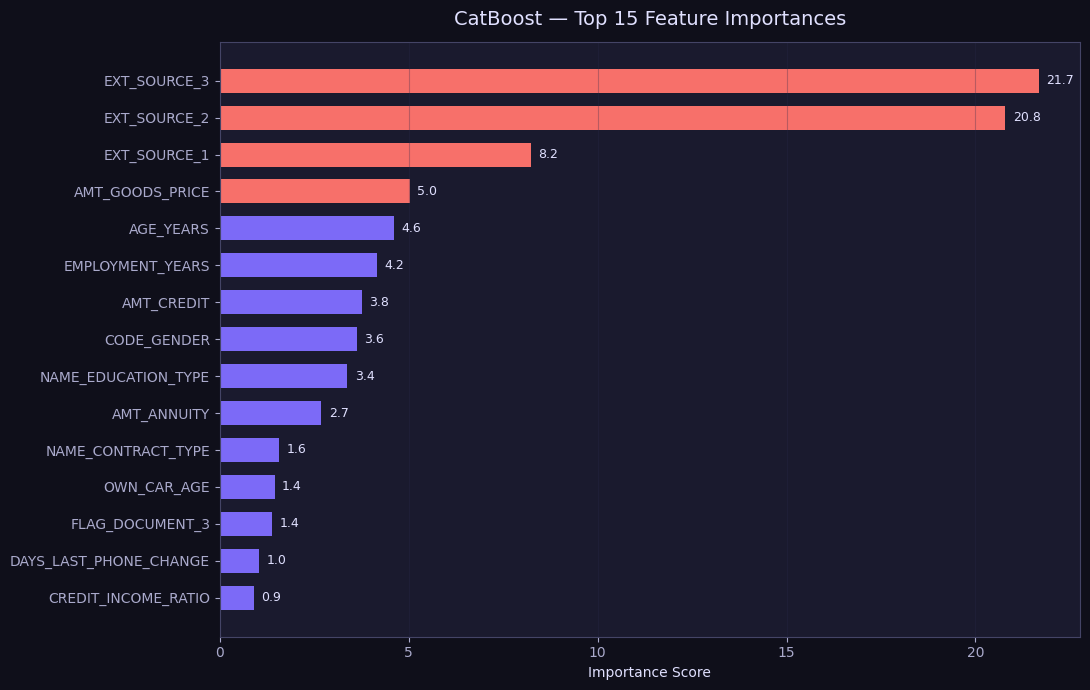


🔑 Top 5 Risk Drivers:
  EXT_SOURCE_3                       : 21.68
  EXT_SOURCE_2                       : 20.79
  EXT_SOURCE_1                       : 8.23
  AMT_GOODS_PRICE                    : 5.02
  AGE_YEARS                          : 4.61


In [21]:
# Top 15 features from CatBoost
fi = pd.Series(cat_model.get_feature_importance(), index=X.columns)
fi = fi.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f1a')
colors_bar = [ACCENT2 if v >= fi.quantile(0.75) else ACCENT for v in fi.values]
bars = ax.barh(fi.index, fi.values, color=colors_bar, edgecolor='none', height=0.65)
for bar, val in zip(bars, fi.values):
    ax.text(val+0.2, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)
ax.set_title('CatBoost — Top 15 Feature Importances', fontsize=14, pad=12)
ax.set_xlabel('Importance Score'); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../images/feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print("\n🔑 Top 5 Risk Drivers:")
for feat, score in fi.tail(5).iloc[::-1].items():
    print(f"  {feat:35s}: {score:.2f}")


## 8. Final Conclusion & Business Recommendations

### Model Performance Summary

The code cells above compute ROC-AUC, average precision, optimal thresholds, confusion matrices, total costs, and savings directly from the current `application_train.csv` data. Exact metric values are intentionally not hard-coded in this markdown cell because they should reflect the current run, library versions, and random seed.

### Key Findings to Verify After Execution

1. **The default threshold of 0.5 should be checked against the cost-optimal threshold** because the false-negative and false-positive costs are unequal.

2. **Threshold optimization should be evaluated by total business cost**, using the confusion matrix counts from the held-out test set.

3. **Feature importance should be read from the generated CatBoost output**, especially the printed Top 5 list and `images/feature_importance.png`.

### Business Recommendations

- Choose the model-threshold pair with the lowest test-set business cost.
- Re-run threshold optimization whenever the portfolio mix, approval policy, or cost assumptions change.
- Monitor the data quality of whichever features appear in the final feature-importance output.
- Segment thresholds by product type or applicant segment only after validating enough holdout volume for each segment.
- Send applicants near the chosen threshold to manual review when operational capacity allows.

### Business Impact

Cost-aware threshold selection connects model probabilities to lending decisions by trading off preventable default losses against missed revenue from rejecting good applicants.


In [22]:
# Final summary printout
print("=" * 60)
print("       TASK 4 — FINAL PERFORMANCE SUMMARY")
print("=" * 60)
print(f"  Dataset Records      : {len(df):,}")
print(f"  Default Rate         : {df['TARGET'].mean()*100:.2f}%")
print(f"\n  Logistic Regression  →  AUC: {lr_auc:.4f}")
print(f"  CatBoost             →  AUC: {cb_auc:.4f}")
print(f"\n  Cost-Optimal Threshold (CatBoost): {cb_opt:.3f}")
print(f"  Cost @ Default 0.5   : ${def_cost:,.0f}")
print(f"  Cost @ Optimal       : ${opt_cost:,.0f}")
print(f"  Savings              : ${def_cost-opt_cost:,.0f}")
print("=" * 60)
print("✅ Task 4 Complete")


       TASK 4 — FINAL PERFORMANCE SUMMARY
  Dataset Records      : 307,511
  Default Rate         : 8.07%

  Logistic Regression  →  AUC: 0.7462
  CatBoost             →  AUC: 0.7568

  Cost-Optimal Threshold (CatBoost): 0.699
  Cost @ Default 0.5   : $124,685,000
  Cost @ Optimal       : $103,760,000
  Savings              : $20,925,000
✅ Task 4 Complete
